#discussion


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df=pd.read_csv('data.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [ ]:
df.columns=df.columns.str.replace(' ','_').str.lower()
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [ ]:
strings=list(df.dtypes.index)
for col in df.columns:
  if df[col].dtypes==object:
    df[col]=df[col].str.replace(' ','_').str.lower()
df.head()


,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [ ]:
for col in df.columns:
  print(col)
  print(df[col].unique()[:5])
  print(df[col].nunique())
  print()

make
['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler']
48

model
['1_series_m' '1_series' '100' '124_spider' '190-class']
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel']
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown']
5

driven_wheels
['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive']
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
['factory_tuner,luxury,high-performance' 'luxury,performance'
 'luxury,high-performance' 'luxury' 'performance']
71

vehicle_size
['compact' 'midsize' 'large']
3

vehicle_style
['coupe' 'convertible' 'sedan' 'wagon' '4dr_hatchback']
16

highway_mpg
[26 28 27 25 24]
59

city_mpg
[19 20 18 17 16]
69

popularity
[3916 3105  819  617 1013]
48

msrp
[46135 40650 36350 29450 345

Distibution of price

<Axes: xlabel='msrp', ylabel='Count'>

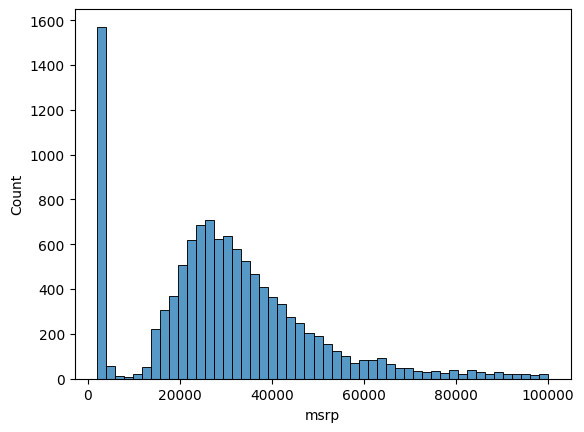

In [ ]:
sns.histplot(df.msrp[df.msrp<100000],bins=50)

#this will suggest the the distribution is long tail

In [ ]:
np.log1p([0,10,20,1000,100000]) #addition of 1 along with the log


array([ 0.        ,  2.39789527,  3.04452244,  6.90875478, 11.51293546])

<Axes: xlabel='msrp', ylabel='Count'>

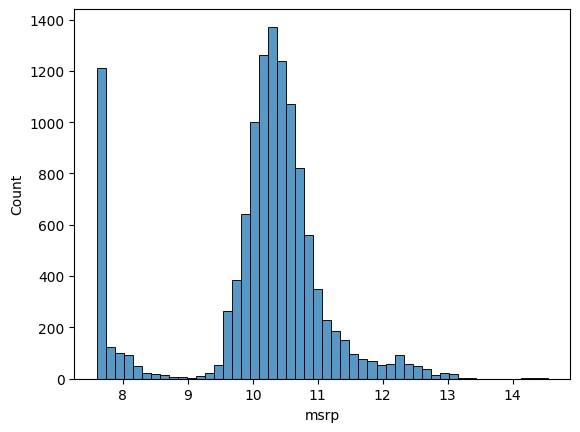

In [ ]:
price_logp=np.log1p(df['msrp'])
price_logp
sns.histplot(price_logp,bins=50)

Missing Values

In [ ]:
df.isnull().sum()

,0
make,0
model,0
year,0
engine_fuel_type,3
engine_hp,69
engine_cylinders,30
transmission_type,0
driven_wheels,0
number_of_doors,6
market_category,3742


#setting up with the Validation framework

In [ ]:
n=len(df)
#we have to shuffle the data first then get hte data
idx=np.arange(n)
np.random.seed(2)
np.random.shuffle(idx)
idx

array([2735, 6720, 5878, ..., 6637, 2575, 7336])

In [ ]:
n=len(df)
n_val=int(len(df)*0.2)
n_test=int(len(df)*0.2)
n_train=n-(n_val+n_test)
n_train+n_val+n_test==n
n_train,n_val,n_test


(7150, 2382, 2382)

In [ ]:
df_train=df.iloc[idx[:n_train]]
df_val=df.iloc[idx[n_train:n_train+n_val]]
df_test=df.iloc[idx[n_train+n_val:]]

In [ ]:
df_train=df_train.reset_index(drop=True)
df_val=df_val.reset_index(drop=True)
df_test=df_test.reset_index(drop=True)
display(df_train.head())

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [ ]:
y_train=np.log1p(df_train.msrp.values)
y_val=np.log1p(df_val.msrp.values)
y_test=np.log1p(df_test.msrp.values)

In [ ]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [ ]:
print(f'Length of y_train: {len(y_train)}, Length of y_val: {len(y_val)}, Length of y_test: {len(y_test)}')


Length of y_train: 7150, Length of y_val: 2382, Length of y_test: 2382


In [ ]:
df_train.iloc[10]

,10
make,rolls-royce
model,phantom_drophead_coupe
year,2015
engine_fuel_type,premium_unleaded_(required)
engine_hp,453.0
engine_cylinders,12.0
transmission_type,automatic
driven_wheels,rear_wheel_drive
number_of_doors,2.0
market_category,"exotic,luxury,performance"


In [ ]:
w0=7.17 #bias term
w=[0.01,0.04,0.002]

In [ ]:
w_new=[w0]+w
w_new

[7.17, 0.01, 0.04, 0.002]

In [ ]:
#[engine_hp,city_mpg,popularity]--feature matrix
xi=[453,11,86]
def linear_regression(xi):
  n=len(xi)
  pred=w0
  for j in range(n):
    pred=pred+w[j]*xi[j]
  #do something
  return pred #predicted


In [ ]:
linear_regression(xi)

12.312

In [ ]:
np.expm1(12.312)

np.float64(222347.2221101062)

Linear Regression generalization

In [ ]:
def dot(xi,w):
  n=len(xi)
  res=0.0
  for j in range(n):
    res+=xi[j]*w[j]
  return res

In [ ]:
#[engine_hp,city_mpg,popularity]--feature matrix
def linear_regression(xi):
  xi=[1]+xi
  return  dot(xi,w_new)#predicted


In [ ]:
def linear_regression(xi):

  return w0 + dot(xi,w)

In [ ]:
linear_regression(xi)

12.312000000000001

In [ ]:
x1=[1,148,24,1385]
x2=[1,132,25,2031]
x10=[1,453,11,86]
x=[x1,x2,x10]
X=np.array(x)

X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [ ]:
def linear_regression(X):
     return X.dot(w_new)

Traning and lernig linear Regression Model

In [ ]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],

    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86]
]
X=np.array(X)


In [ ]:
ones=np.ones(X.shape[0])
ones

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [ ]:
X=np.column_stack([ones,X])
X

array([[1.000e+00, 1.480e+02, 2.400e+01, 1.385e+03],
       [1.000e+00, 1.320e+02, 2.500e+01, 2.031e+03],
       [1.000e+00, 4.530e+02, 1.100e+01, 8.600e+01],
       [1.000e+00, 1.580e+02, 2.400e+01, 1.850e+02],
       [1.000e+00, 1.720e+02, 2.500e+01, 2.010e+02],
       [1.000e+00, 4.130e+02, 1.100e+01, 8.600e+01],
       [1.000e+00, 3.800e+01, 5.400e+01, 1.850e+02],
       [1.000e+00, 1.420e+02, 2.500e+01, 4.310e+02],
       [1.000e+00, 4.530e+02, 3.100e+01, 8.600e+01]])

In [ ]:
gram_mat=X.T.dot(X)
gram_mat

array([[9.000000e+00, 2.109000e+03, 2.300000e+02, 4.676000e+03],
       [2.109000e+03, 6.964710e+05, 4.411500e+04, 7.185400e+05],
       [2.300000e+02, 4.411500e+04, 7.146000e+03, 1.188030e+05],
       [4.676000e+03, 7.185400e+05, 1.188030e+05, 6.359986e+06]])

In [ ]:
gm_inv=np.linalg.inv(gram_mat)
gm_inv

array([[ 3.30686958e+00, -5.39612291e-03, -6.21325581e-02,
        -6.61016816e-04],
       [-5.39612291e-03,  1.11633857e-05,  8.66973393e-05,
         1.08664195e-06],
       [-6.21325581e-02,  8.66973393e-05,  1.46189255e-03,
         8.57849603e-06],
       [-6.61016816e-04,  1.08664195e-06,  8.57849603e-06,
         3.60215866e-07]])

In [ ]:
y=[100,200,300,400,200,300,202,121,323]
w_full=gm_inv.dot(X.T).dot(y)
w0=w_full[0]
w=w_full[1:]

In [ ]:
def Train_linear_regression(X,Y):
  ones=np.ones(X.shape[0])
  X=np.column_stack([ones,X])
  gram_mat=X.T.dot(X)
  gm_inv=np.linalg.inv(gram_mat)
  w_full=gm_inv.dot(X.T).dot(Y)
  return w_full[0],w_full[1:]

#baseline car price Model


In [ ]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='object')

In [ ]:
base=['engine_hp','engine_cylinders','highway_mpg','popularity']
df_train[base]

,engine_hp,engine_cylinders,highway_mpg,popularity
0,148.0,4.0,33,1385
1,132.0,4.0,32,2031
2,148.0,4.0,37,640
3,90.0,4.0,18,873
4,385.0,8.0,21,5657
...,...,...,...,...
7145,300.0,6.0,31,3916
7146,210.0,4.0,30,873
7147,285.0,6.0,22,549
7148,563.0,12.0,21,86


In [ ]:
df_train[base].isnull().sum()
df_train[base].fillna(0).isnull().sum()

,0
engine_hp,0
engine_cylinders,0
highway_mpg,0
popularity,0


In [ ]:
x_train=df_train[base].values
x_train

array([[ 148.,    4.,   33., 1385.],
       [ 132.,    4.,   32., 2031.],
       [ 148.,    4.,   37.,  640.],
       ...,
       [ 285.,    6.,   22.,  549.],
       [ 563.,   12.,   21.,   86.],
       [ 200.,    4.,   31.,  873.]])

In [ ]:
x_train=df_train[base].fillna(0).values
x_train

array([[ 148.,    4.,   33., 1385.],
       [ 132.,    4.,   32., 2031.],
       [ 148.,    4.,   37.,  640.],
       ...,
       [ 285.,    6.,   22.,  549.],
       [ 563.,   12.,   21.,   86.],
       [ 200.,    4.,   31.,  873.]])

In [ ]:
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978])

In [ ]:
w0,w=Train_linear_regression(x_train,y_train)
w0,w

(np.float64(7.958512361380224),
 array([ 9.65531808e-03, -1.65513374e-01,  2.59968087e-02, -7.22026238e-06]))

In [ ]:
y_pred=w0+x_train.dot(w)
y_pred

array([ 9.57334057,  9.38819438,  9.6827069 , ..., 10.28516364,
       11.953608  , 10.02712026])

<Axes: ylabel='Count'>

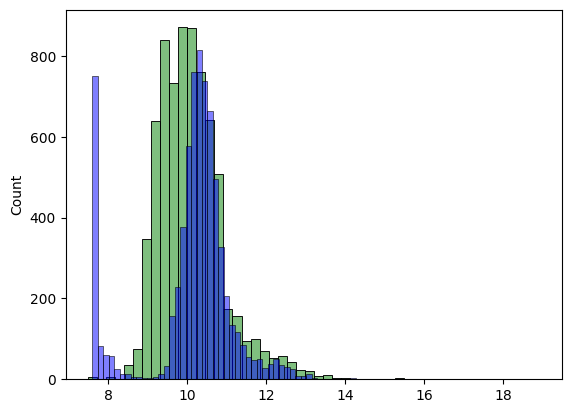

In [ ]:
sns.histplot(y_pred,color='g',bins=50,alpha=0.5)
sns.histplot(y_train,color='b',bins=50,alpha=0.5)

#RMSE

In [ ]:
def rmse(y,y_pred):
  error=y-y_pred
  sqer=error**2
  mse=sqer.mean()
  return np.sqrt(mse)


In [ ]:
rmse(y_train,y_pred)

np.float64(0.7585356196570802)

#validating the model

In [ ]:
base=['engine_hp','engine_cylinders','highway_mpg','popularity']

x_train=df_train[base].fillna(0).values

w0,w=Train_linear_regression(x_train,y_train)

y_pred=w0+x_train.dot(w)

In [ ]:
def prepare_X(df):
  df_num=df[base]
  df_num=df_num.fillna(0)
  X=df_num.values
  return X



In [ ]:
X_train=prepare_X(df_train)

w0,w=Train_linear_regression(X_train,y_train)#training part
# ---------validation part----------
X_val=prepare_X(df_val)

y_pred=w0+X_val.dot(w)

rmse(y_val,y_pred)

np.float64(0.7584534549012494)

Feature engineering

In [ ]:
2017-df_train.year

,year
0,9
1,5
2,1
3,26
4,0
...,...
7145,2
7146,2
7147,2
7148,3


In [ ]:
base


['engine_hp', 'engine_cylinders', 'highway_mpg', 'popularity']

In [ ]:
def prepare_X(df):
  df=df.copy()#this will not make the change in the original data types
  df['age']=2017-df.year
  features=base+['age']
  df_num=df[features]

  df_num=df_num.fillna(0)
  X=df_num.values
  return X



In [ ]:
X_train=prepare_X(df_train)
df_train.dtypes # The 'age' column was added internally in prepare_X, not to the original df_train
df_train.columns


Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'number_doors_2',
       'number_doors_3', 'number_doors_4'],
      dtype='object')

In [ ]:
X_train=prepare_X(df_train)
w0,w=Train_linear_regression(X_train,y_train)

X_val=prepare_X(df_val)
y_pred_val=w0+X_val.dot(w)
rmse_val=rmse(y_val,y_pred_val)
print(f'RMSE on validation set: {rmse_val}')




RMSE on validation set: 0.5183283894856089


<Axes: ylabel='Count'>

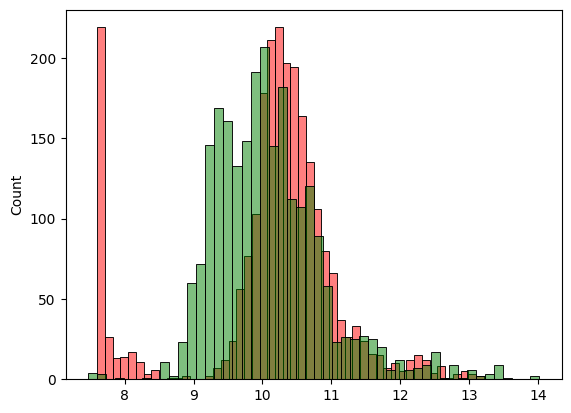

In [ ]:
sns.histplot(y_val,alpha=0.5,color='r',bins=50)
sns.histplot(y_pred,alpha=0.5,color='g',bins=50)

Catagorical variable

In [ ]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'number_doors_2',
       'number_doors_3', 'number_doors_4'],
      dtype='object')

In [ ]:
del df

In [ ]:
for v in [2,3,4]:
  df_train['number_doors_%s' %v]=(df_train.number_of_doors==v).astype('int')

In [ ]:
def prepare_X(df):
  df=df.copy()#this will not make the change in the original data types
  df['age']=2017-df.year
  features=base.copy()
  features.append('age')
  for v in [2,3,4]:
      df['number_doors_%s' %v]=(df.number_of_doors==v).astype('int')
      features.append('number_doors_%s' %v)

  df_num=df[features]
  df_num=df_num.fillna(0)
  X=df_num.values
  return X


In [ ]:
X_train=prepare_X(df_train)
w0,w=Train_linear_regression(X_train,y_train)

X_val=prepare_X(df_val)
y_pred_val=w0+X_val.dot(w)
rmse_val=rmse(y_val,y_pred_val)
print(f'RMSE on validation set: {rmse_val}')



RMSE on validation set: 0.5174432597020047


In [ ]:
df.make.nunique()

48

In [ ]:
makes=list(df.make.value_counts().head().index)

In [ ]:
def prepare_X(df):
  df=df.copy()#this will not make the change in the original data types
  df['age']=2017-df.year
  features=base.copy()
  features.append('age')
  for v in [2,3,4]:
      df['number_doors_%s' %v]=(df.number_of_doors==v).astype('int')
      features.append('number_doors_%s' %v)
  for v in makes:
      df['makes_%s' %v]=(df.make==v).astype('int')
      features.append('makes_%s' %v)
  df_num=df[features]
  df_num=df_num.fillna(0)
  X=df_num.values
  return X

In [ ]:
X_train=prepare_X(df_train)
w0,w=Train_linear_regression(X_train,y_train)

X_val=prepare_X(df_val)
y_pred_val=w0+X_val.dot(w)
rmse_val=rmse(y_val,y_pred_val)
print(f'RMSE on validation set: {rmse_val}')



RMSE on validation set: 0.5100217382880057


In [ ]:
categorical_var = [
    'make',
    'engine_fuel_type',
    'transmission_type',
    'driven_wheels',
    'market_category',
    'vehicle_size',
    'vehicle_style'
]


In [ ]:
catagories={}
for c in categorical_var :
  catagories[c]=list(df[c].value_counts().head().index)



In [ ]:
catagories

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'transmission_type': ['automatic',
  'manual',
  'automated_manual',
  'direct_drive',
  'unknown'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'luxury,performance',
  'hatchback'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [ ]:
def prepare_X(df):
  df=df.copy()#this will not make the change in the original data types
  df['age']=2017-df.year
  features=base.copy()
  features.append('age') # Corrected typo from 'appedn' to 'append'
  for v in [2,3,4]:
      df['number_doors_%s' %v]=(df.number_of_doors==v).astype('int')
      features.append('number_doors_%s' %v)
  for c,value in catagories.items():
    for v in value:
      df['%s_%s' %(c,v)]=(df[c]==v).astype('int')
      features.append('%s_%s' %(c,v))
  df_num=df[features]
  df_num=df_num.fillna(0)
  X=df_num.values
  return X

In [ ]:
X_train=prepare_X(df_train)
w0,w=Train_linear_regression(X_train,y_train)

X_val=prepare_X(df_val)
y_pred_val=w0+X_val.dot(w)
rmse_val=rmse(y_val,y_pred_val)
print(f'RMSE on validation set: {rmse_val}')
#this is because the same feature value and sometimes inverse not exit



RMSE on validation set: 43.775558776611675


#Regularization

In [ ]:
def Train_linear_regression_reg(X,Y,r=0.0001):
  ones=np.ones(X.shape[0])
  X=np.column_stack([ones,X])
  gram_mat=X.T.dot(X)
  gram_mat=gram_mat+ r * np.eye(gram_mat.shape[0])
  gm_inv=np.linalg.inv(gram_mat)
  w_full=gm_inv.dot(X.T).dot(Y)
  return w_full[0],w_full[1:]

In [ ]:
X_train=prepare_X(df_train)
w0,w=Train_linear_regression_reg(X_train,y_train,r=0.001)

X_val=prepare_X(df_val)
y_pred_val=w0+X_val.dot(w)
rmse_val=rmse(y_val,y_pred_val)
print(f'RMSE on validation set: {rmse_val}')

RMSE on validation set: 0.45666981281060853


In [ ]:
for r in [10,0,0.01,0.0001,0.001,100,10000,0.00001]:
  X_train=prepare_X(df_train)
  w0,w=Train_linear_regression_reg(X_train,y_train,r=r)

  X_val=prepare_X(df_val)
  y_pred_val=w0+X_val.dot(w)
  rmse_val=rmse(y_val,y_pred_val)
  print(r,w0,rmse_val)
#we choose the r==0.0001

10 4.4144172558996315 0.4667641917358345
0 2941075705502919.5 43.775558776611675
0.01 6.222764871676685 0.45667601663885105
0.0001 6.217168325761338 0.45666919639860903
0.001 6.23190808129373 0.45666981281060853
100 2.597082406464061 0.5646830324468755
10000 0.13556462138474998 1.2144377727571092
1e-05 6.056938688927374 0.4566691072464155


In [ ]:
X_train=prepare_X(df_train)
w0,w=Train_linear_regression_reg(X_train,y_train,r=0.0001)

X_val=prepare_X(df_val)
y_pred_val=w0+X_val.dot(w)
rmse_val=rmse(y_val,y_pred_val)
print(f'RMSE on validation set: {rmse_val}')

RMSE on validation set: 0.5183283901605541


Using the model

In [ ]:
#for testing the model
full_train=pd.concat([df_train,df_val])
full_train=full_train.reset_index(drop=True)
full_train



,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,number_doors_2,number_doors_3,number_doors_4
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,1.0,0.0,0.0
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,0.0,0.0,1.0
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,0.0,0.0,1.0
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,0.0,1.0,0.0
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9527,volvo,v60,2015,regular_unleaded,240.0,4.0,automatic,front_wheel_drive,4.0,luxury,midsize,wagon,37,25,870,NaN,NaN,NaN
9528,maserati,granturismo_convertible,2015,premium_unleaded_(required),444.0,8.0,automatic,rear_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,convertible,20,13,238,NaN,NaN,NaN
9529,cadillac,escalade_hybrid,2013,regular_unleaded,332.0,8.0,automatic,rear_wheel_drive,4.0,"luxury,hybrid",large,4dr_suv,23,20,1624,NaN,NaN,NaN
9530,mitsubishi,lancer,2016,regular_unleaded,148.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,sedan,34,24,436,NaN,NaN,NaN


In [ ]:
X_full_train=prepare_X(full_train)
X_full_train

array([[1.480e+02, 4.000e+00, 3.300e+01, 1.385e+03, 9.000e+00],
       [1.320e+02, 4.000e+00, 3.200e+01, 2.031e+03, 5.000e+00],
       [1.480e+02, 4.000e+00, 3.700e+01, 6.400e+02, 1.000e+00],
       ...,
       [3.320e+02, 8.000e+00, 2.300e+01, 1.624e+03, 4.000e+00],
       [1.480e+02, 4.000e+00, 3.400e+01, 4.360e+02, 1.000e+00],
       [2.900e+02, 6.000e+00, 2.500e+01, 1.720e+03, 2.000e+00]])

In [ ]:
y_full_train=np.concatenate([y_train,y_val])
y_full_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 11.21756062,
        9.77542688, 10.1924563 ])

In [ ]:
w0,w=Train_linear_regression_reg(X_full_train,y_full_train,0.0001)
w0,w

(np.float64(9.314905892480244),
 array([ 3.67566124e-03,  7.50267000e-02,  5.87962347e-03, -4.51314197e-05,
        -9.37978761e-02]))

In [ ]:
X_val=prepare_X(df_test)
y_pred=w0+X_val.dot(w)
rmse_val=rmse(y_test,y_pred)
rmse_val

np.float64(0.5180257294426284)

<Axes: ylabel='Count'>

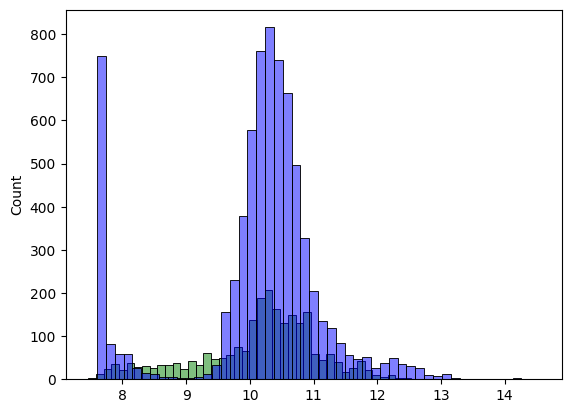

In [ ]:
sns.histplot(y_pred,color='g',bins=50,alpha=0.5)
sns.histplot(y_train,color='b',bins=50,alpha=0.5)

In [ ]:
car=df_test.iloc[20].to_dict()
car

{'make': 'toyota',
 'model': 'sienna',
 'year': 2015,
 'engine_fuel_type': 'regular_unleaded',
 'engine_hp': 266.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'front_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': nan,
 'vehicle_size': 'large',
 'vehicle_style': 'passenger_minivan',
 'highway_mpg': 25,
 'city_mpg': 18,
 'popularity': 2031}

In [ ]:
df_small=pd.DataFrame([car])
df_small

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,toyota,sienna,2015,regular_unleaded,266.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,passenger_minivan,25,18,2031


In [ ]:
X_small=prepare_X(df_small)
y_pred=w0+X_small.dot(w)
y_pred=y_pred[0]
y_pred


np.float64(10.449749633605178)

In [ ]:
#actual value
np.expm1(y_pred)

np.float64(34534.72704130832)

In [ ]:
y_test[20]

np.float64(10.463131911491967)

In [ ]:
np.expm1(y_test[20])

np.float64(35000.00000000001)